In [1]:
from pathlib import Path
import pandas as pd
import json

PROJECT_ROOT = Path.cwd().parent.parent
MODEL_RUNS_DIR = PROJECT_ROOT / "results" / "model_runs"

final_run_dirs = sorted(MODEL_RUNS_DIR.glob("random_forest_final_*"))
latest_run_dir = final_run_dirs[-1]

print("Latest final RF run:")
print(latest_run_dir)

test_metrics_file = latest_run_dir / "test_metrics.csv"
threshold_file = latest_run_dir / "threshold_sweep.csv"
importance_file = latest_run_dir / "permutation_importance.csv"
best_params_file = latest_run_dir / "best_params.json"
predictions_file = latest_run_dir / "test_predictions.csv"

print("\nExists?")
for f in [test_metrics_file, threshold_file, importance_file, best_params_file, predictions_file]:
    print(f.name, "->", f.exists())

test_metrics_df = pd.read_csv(test_metrics_file)
threshold_df = pd.read_csv(threshold_file)
permutation_importance_df = pd.read_csv(importance_file)

with open(best_params_file, "r") as f:
    best_params = json.load(f)

test_metrics_df

Latest final RF run:
c:\Users\john\Desktop\spring-2026-radon-risk-mapping\results\model_runs\random_forest_final_final_refit_test_eval_2026_03_20_20260320_135505

Exists?
test_metrics.csv -> True
threshold_sweep.csv -> True
permutation_importance.csv -> True
best_params.json -> True
test_predictions.csv -> True


,model_name,run_id,search_scoring,n_train_rows,n_test_rows,train_positive_rate,test_positive_rate,test_roc_auc,test_aucpr,test_log_loss,...,test_accuracy_at_0p10,test_recall_at_0p10,test_f1_at_0p10,test_accuracy_at_0p15,test_recall_at_0p15,test_f1_at_0p15,predicted_positive_rate_at_0p10,predicted_positive_rate_at_0p15,best_inner_cv_score,best_params_json
0,random_forest_final,random_forest_final_final_refit_test_eval_2026...,neg_log_loss,10461,2616,0.108594,0.129587,0.66052,0.247726,0.366166,...,0.478976,0.752212,0.27229,0.78211,0.389381,0.316547,0.586391,0.18922,-0.326626,"{""classifier__bootstrap"": true, ""classifier__c..."


In [2]:
oof_reference_rf = pd.DataFrame([{
    "model_name": "random_forest_oof_reference",
    "roc_auc": 0.649478,
    "aucpr": 0.183600,
    "log_loss": 0.329423,
    "brier": 0.093914,
    "ece": 0.001278,
    "f1_at_0p10": 0.248204,
    "recall_at_0p10": 0.669014,
}])

final_test_summary = pd.DataFrame([{
    "model_name": "random_forest_final_test",
    "roc_auc": test_metrics_df.loc[0, "test_roc_auc"],
    "aucpr": test_metrics_df.loc[0, "test_aucpr"],
    "log_loss": test_metrics_df.loc[0, "test_log_loss"],
    "brier": test_metrics_df.loc[0, "test_brier"],
    "ece": test_metrics_df.loc[0, "test_ece"],
    "f1_at_0p10": test_metrics_df.loc[0, "test_f1_at_0p10"],
    "recall_at_0p10": test_metrics_df.loc[0, "test_recall_at_0p10"],
}])

pd.concat([oof_reference_rf, final_test_summary], ignore_index=True)

,model_name,roc_auc,aucpr,log_loss,brier,ece,f1_at_0p10,recall_at_0p10
0,random_forest_oof_reference,0.649478,0.183600,0.329423,0.093914,0.001278,0.248204,0.669014
1,random_forest_final_test,0.660520,0.247726,0.366166,0.107828,0.008333,0.272290,0.752212


In [3]:
threshold_df

,threshold,accuracy,recall,f1,predicted_positive_rate
0,0.05,0.136850,1.000000,0.230926,0.992737
1,0.10,0.478976,0.752212,0.272290,0.586391
2,0.15,0.782110,0.389381,0.316547,0.189220
3,0.20,0.831422,0.250737,0.278232,0.103976
4,0.25,0.861621,0.109145,0.169725,0.037080
5,0.30,0.870413,0.000000,0.000000,0.000000


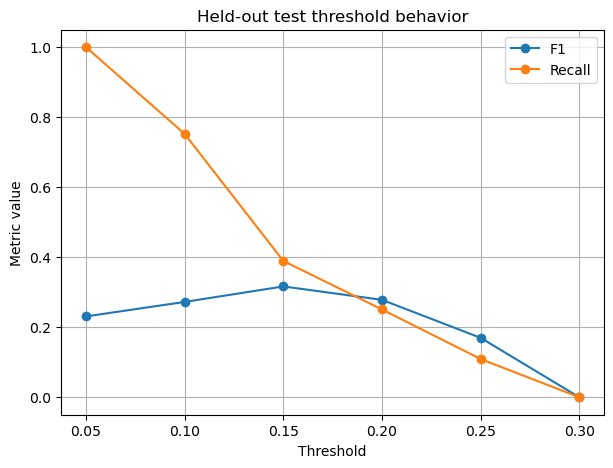

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("Held-out test threshold behavior")
plt.legend()
plt.grid(True)
plt.show()

In [5]:
permutation_importance_df.head(20)

,feature,importance_mean,importance_std
0,geolprov_interior_platform,0.002015,0.000695
1,socioeco_frac_housing_burden,0.001471,0.000706
2,mean_uranium,0.001429,0.000365
3,socioeco_median_income,0.001191,0.000483
4,longitude,0.001140,0.000304
5,hous_frac_type_single_detached,0.001108,0.000411
6,socioeco_frac_high_income,0.001000,0.000389
7,rxtp_sedimentary_rocks,0.000984,0.000295
8,hous_median_value,0.000962,0.000345
9,rxtp_intrusive_rocks,0.000863,0.000304


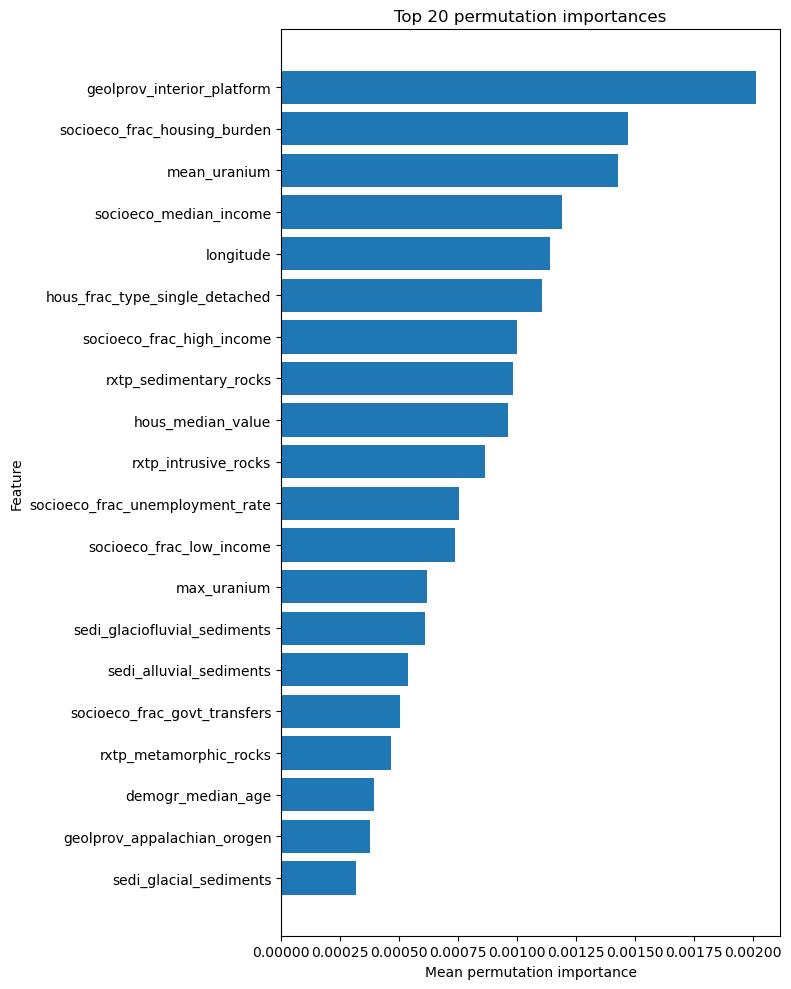

In [6]:
top_k = 20
plot_df = permutation_importance_df.head(top_k).iloc[::-1]

plt.figure(figsize=(8, 10))
plt.barh(plot_df["feature"], plot_df["importance_mean"])
plt.xlabel("Mean permutation importance")
plt.ylabel("Feature")
plt.title("Top 20 permutation importances")
plt.tight_layout()
plt.show()